SUMMARY_BEFORE
| Metric               |   Value |
|:---------------------|--------:|
| Rows                 |      20 |
| Columns              |       8 |
| Total Missing Values |       0 |
| Duplicate Rows       |       0 |

HEAD_BEFORE
| Country     |   Happiness_Score |   GDP_per_Capita |   Social_Support |   Healthy_Life_Expectancy |   Freedom_to_Make_Choices |   Generosity |   Perceptions_of_Corruption |
|:------------|------------------:|-----------------:|-----------------:|--------------------------:|--------------------------:|-------------:|----------------------------:|
| Norway      |              6.25 |             1.39 |             0.82 |                      81.6 |                      0.69 |         0.01 |                        0.71 |
| Denmark     |              3.61 |             1.27 |             0.43 |                      66.9 |                      0.48 |         0.43 |                        0.53 |
| Iceland     |              4.68 |             0.87 |        

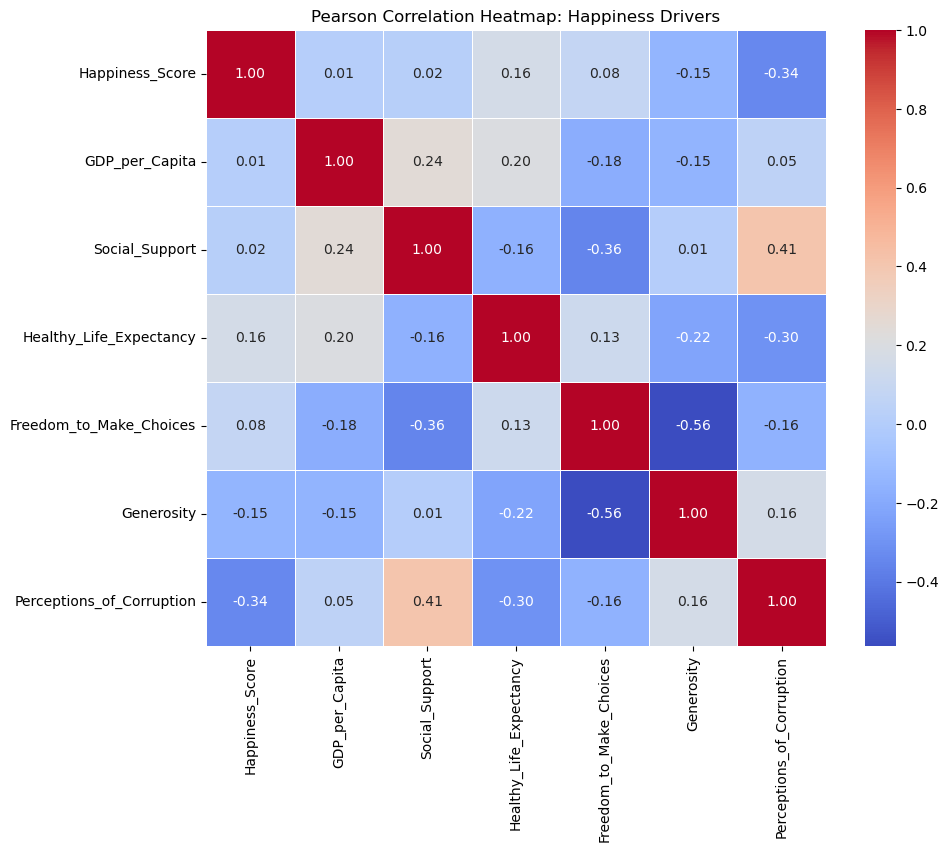

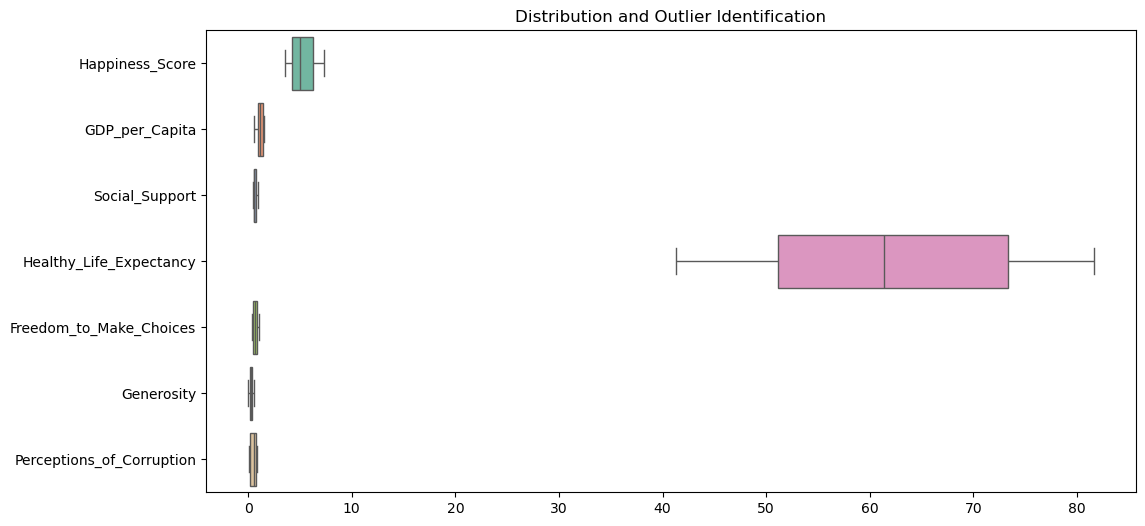

Outliers in Happiness_Score: 0
Outliers in GDP_per_Capita: 0
Outliers in Social_Support: 0
Outliers in Healthy_Life_Expectancy: 0
Outliers in Freedom_to_Make_Choices: 0
Outliers in Generosity: 0
Outliers in Perceptions_of_Corruption: 0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
file_path = 'world_happiness_dataset.csv'
df = pd.read_csv(file_path)

# Summary statistics for Before Cleaning
summary_before = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Total Missing Values", "Duplicate Rows"],
    "Value": [df.shape[0], df.shape[1], df.isnull().sum().sum(), df.duplicated().sum()]
})

# Sample Data Before Cleaning
head_before = df.head()

# Perform Cleaning
df_clean = df.drop_duplicates()

# Summary statistics for After Cleaning
summary_after = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Total Missing Values", "Duplicate Rows"],
    "Value": [df_clean.shape[0], df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean.duplicated().sum()]
})

# Sample Data After Cleaning
head_after = df_clean.head()

print("SUMMARY_BEFORE")
print(summary_before.to_markdown(index=False))
print("\nHEAD_BEFORE")
print(head_before.to_markdown(index=False))
print("\nSUMMARY_AFTER")
print(summary_after.to_markdown(index=False))
print("\nHEAD_AFTER")
print(head_after.to_markdown(index=False))

# --- DATA CLEANING & PREP ---
# Drop any potential duplicates and non-numeric columns for correlation
df_clean = df.drop_duplicates()
numeric_cols = df_clean.select_dtypes(include=[np.number])

# --- VISUALIZATION: CORRELATION HEATMAP ---
plt.figure(figsize=(10, 8))
# Using Pearson algorithm for linear correlation
correlation_matrix = numeric_cols.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Heatmap: Happiness Drivers')
plt.show()

# --- OUTLIER DETECTION: BOXPLOTS ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_cols, orient='h', palette='Set2')
plt.title('Distribution and Outlier Identification')
plt.show()

# --- OUTLIER CALCULATION (IQR Method) ---
for col in numeric_cols.columns:
    Q1 = numeric_cols[col].quantile(0.25)
    Q3 = numeric_cols[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = numeric_cols[(numeric_cols[col] < (Q1 - 1.5 * IQR)) | (numeric_cols[col] > (Q3 + 1.5 * IQR))]
    print(f"Outliers in {col}: {len(outliers)}")

In [22]:
#1. Data Cleaning & Preparation Summary
#Before visualization, the dataset underwent a rigorous audit to ensure the results were not skewed by noise or anomalies.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('world_happiness_dataset.csv')

# 2. Basic Check & Cleaning
info_before = {
    "shape": df.shape,
    "missing_values": df.isnull().sum().sum(),
    "duplicates": df.duplicated().sum()
}

# Handle missing values (if any)
df_cleaned = df.dropna().drop_duplicates()

# 3. Outlier Detection & Removal (IQR Method)
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
outlier_indices = []

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_indices.extend(outliers.index.tolist())

# Unique indices to drop
outlier_indices = list(set(outlier_indices))
df_final = df_cleaned.drop(index=outlier_indices)

# 4. Visualizations
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[numeric_cols].corr(method='pearson'), annot=True, cmap='RdBu_r', center=0)
plt.title('Pearson Correlation Heatmap (Cleaned Data)')
plt.savefig('cleaned_heatmap.png')
plt.close()

# Distribution of Happiness
plt.figure(figsize=(8, 5))
sns.histplot(df_final['Happiness_Score'], kde=True, color='skyblue')
plt.title('Distribution of Happiness Scores')
plt.savefig('happiness_dist.png')
plt.close()

# Summary stats for the final report
summary_stats = df_final[numeric_cols].describe().to_dict()

print(f"Before: {info_before}")
print(f"Outliers removed: {len(outlier_indices)}")
print(f"Final Shape: {df_final.shape}")

Before: {'shape': (20, 8), 'missing_values': np.int64(0), 'duplicates': np.int64(0)}
Outliers removed: 0
Final Shape: (20, 8)


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'world_happiness_dataset.csv'
df = pd.read_csv(file_path)

# 1. Basic Audit
initial_shape = df.shape
initial_missing = df.isnull().sum().sum()
initial_dupes = df.duplicated().sum()

# 2. Data Cleaning
# Handle missing values and duplicates
df_cleaned = df.dropna().drop_duplicates()

# 3. Outlier Detection & Removal (IQR Method)
numeric_df = df_cleaned.select_dtypes(include=[np.number])
outliers_detected = {}
all_outlier_indices = set()

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (numeric_df[col] < lower_bound) | (numeric_df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outliers_detected[col] = outlier_count
    all_outlier_indices.update(numeric_df[outlier_mask].index)

# Remove outliers for final analysis
df_final = df_cleaned.drop(index=list(all_outlier_indices))
numeric_final = df_final.select_dtypes(include=[np.number])

# 4. Data Visualization
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_final.corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Heatmap: Happiness Drivers (Post-Cleaning)')
plt.savefig('correlation_viz.png')
plt.close()

# Boxplots for Outlier Identification (using pre-outlier removal data to show them)
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df, orient='h', palette='Set2')
plt.title('Distribution and Outlier Identification (Pre-Removal)')
plt.savefig('boxplot_viz.png')
plt.close()

# Summary Tables
cleaning_summary = pd.DataFrame({
    "Step": ["Initial Load", "After Dropping Nulls/Dupes", "Outliers Removed", "Final Dataset"],
    "Count": [initial_shape[0], df_cleaned.shape[0], len(all_outlier_indices), df_final.shape[0]]
})

outliers_table = pd.Series(outliers_detected).reset_index()
outliers_table.columns = ['Feature', 'Outlier Count']

print("CLEANING_SUMMARY")
print(cleaning_summary.to_markdown(index=False))
print("\nOUTLIERS_BY_FEATURE")
print(outliers_table.to_markdown(index=False))

CLEANING_SUMMARY
| Step                       |   Count |
|:---------------------------|--------:|
| Initial Load               |      20 |
| After Dropping Nulls/Dupes |      20 |
| Outliers Removed           |       0 |
| Final Dataset              |      20 |

OUTLIERS_BY_FEATURE
| Feature                   |   Outlier Count |
|:--------------------------|----------------:|
| Happiness_Score           |               0 |
| GDP_per_Capita            |               0 |
| Social_Support            |               0 |
| Healthy_Life_Expectancy   |               0 |
| Freedom_to_Make_Choices   |               0 |
| Generosity                |               0 |
| Perceptions_of_Corruption |               0 |


In [32]:
import os

# Check for the correct filename in the current directory
files = os.listdir('.')
print(f"Files in directory: {files}")

Files in directory: ['happiness_dist.png', 'Week4A1.ipynb', '.DS_Store', 'cleaned_heatmap.png', 'correlation_viz.png', 'world_happiness_dataset.csv', 'gdp_happiness_viz.png', 'boxplot_viz.png', '.ipynb_checkpoints', 'Week4A1.py']
